In [30]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [31]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
print("Dataset Info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Emba

In [33]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


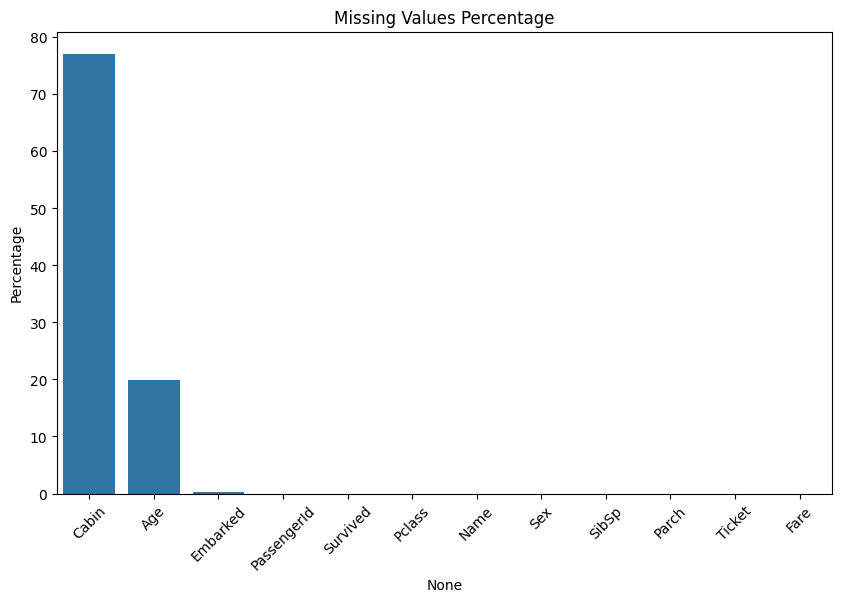


Missing Values Count:
Cabin: 687 (77.10%)
Age: 177 (19.87%)
Embarked: 2 (0.22%)


In [34]:
plt.figure(figsize=(10, 6))
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

sns.barplot(x=missing_data.index, y=missing_percent)
plt.title('Missing Values Percentage')
plt.xticks(rotation=45)
plt.ylabel('Percentage')
plt.show()

print("\nMissing Values Count:")
for col in missing_data.index:
    if missing_data[col] > 0:
        print(f"{col}: {missing_data[col]} ({missing_percent[col]:.2f}%)")

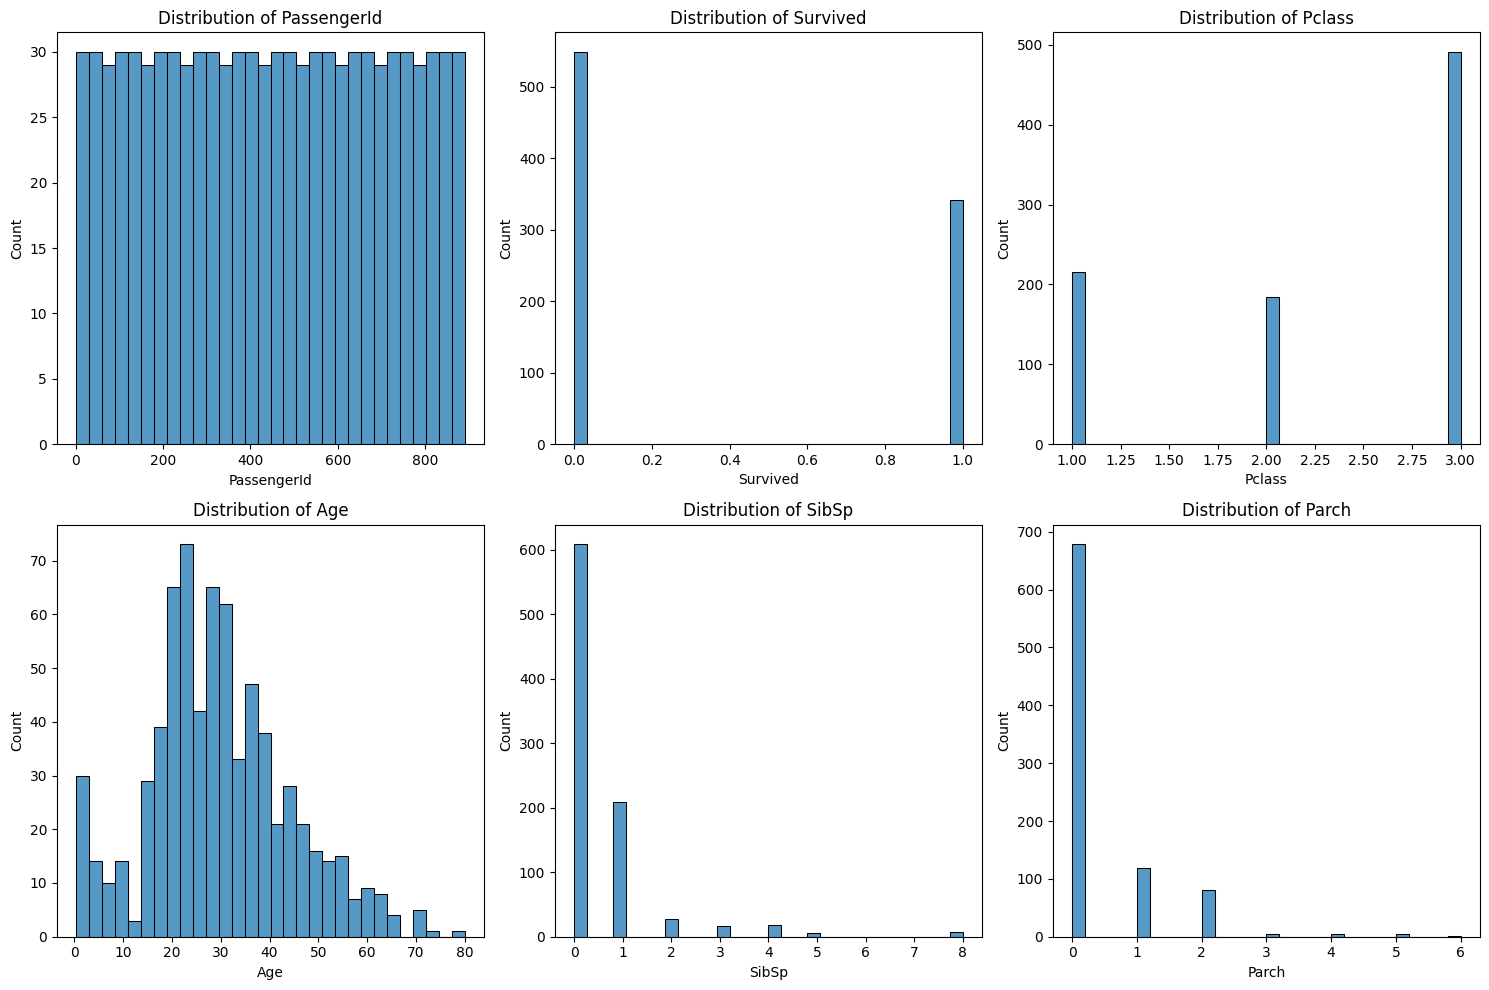

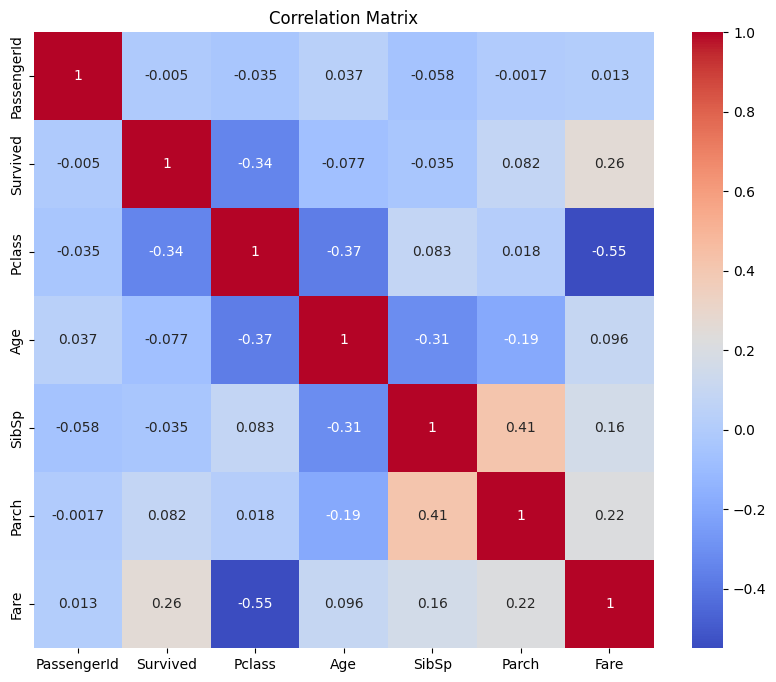

In [35]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.histplot(data=df, x=col, bins=30, ax=axes[idx])
        axes[idx].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Categorical Features Distribution


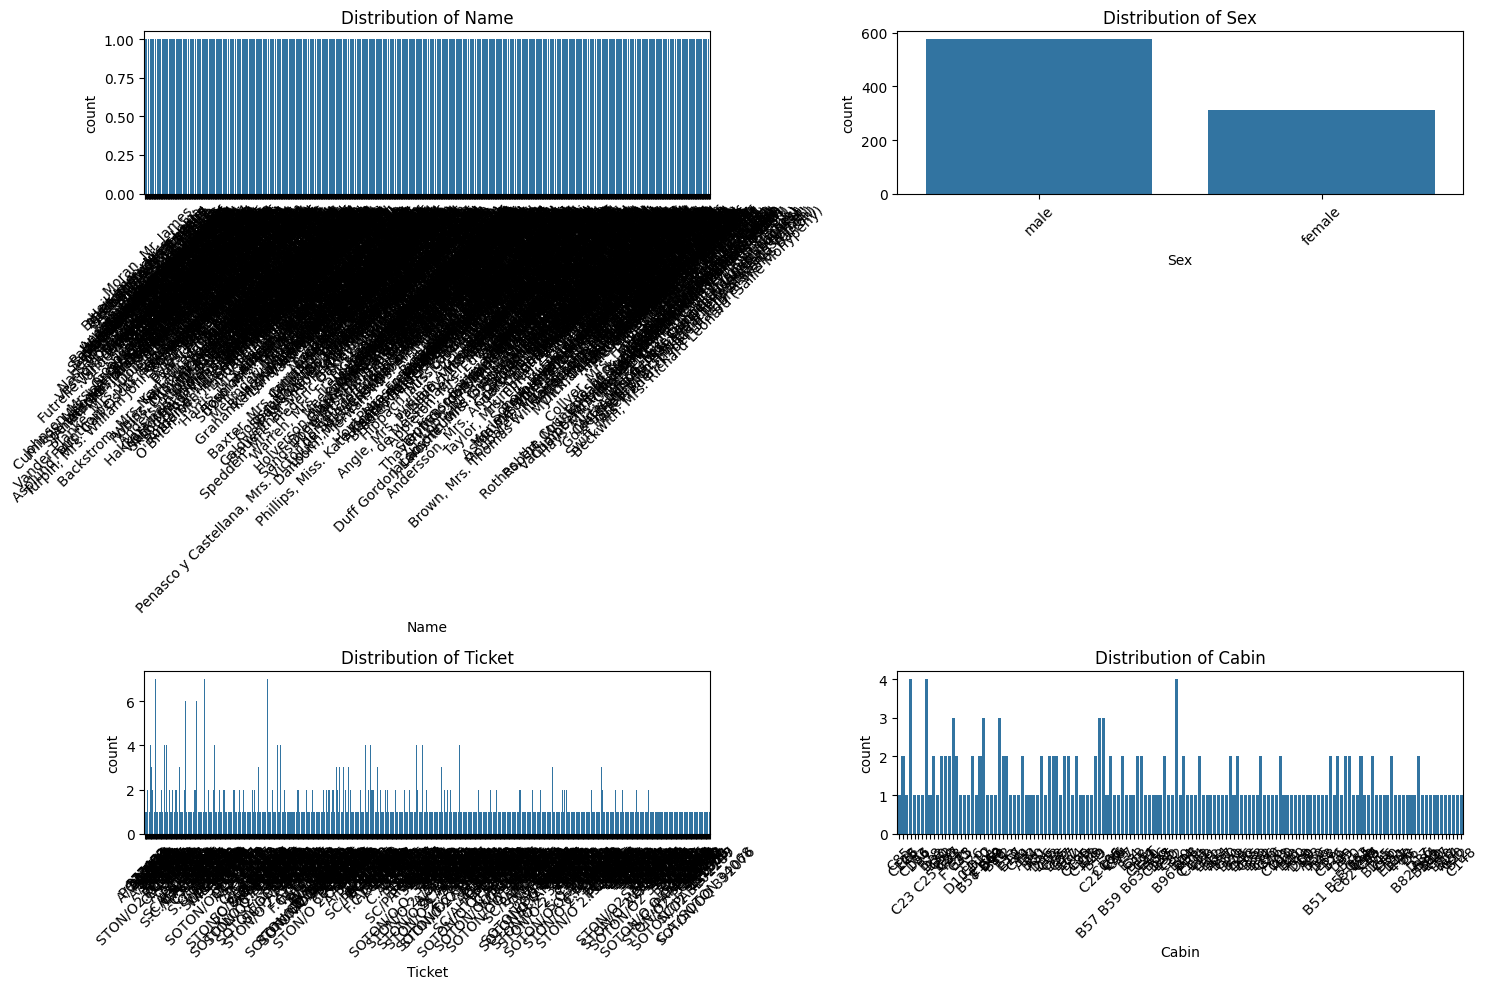

In [36]:

categorical_cols = df.select_dtypes(include=['object']).columns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        sns.countplot(data=df, x=col, ax=axes[idx])
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].tick_params(axis='x', rotation=45)
print("Categorical Features Distribution")
plt.tight_layout()
plt.show()

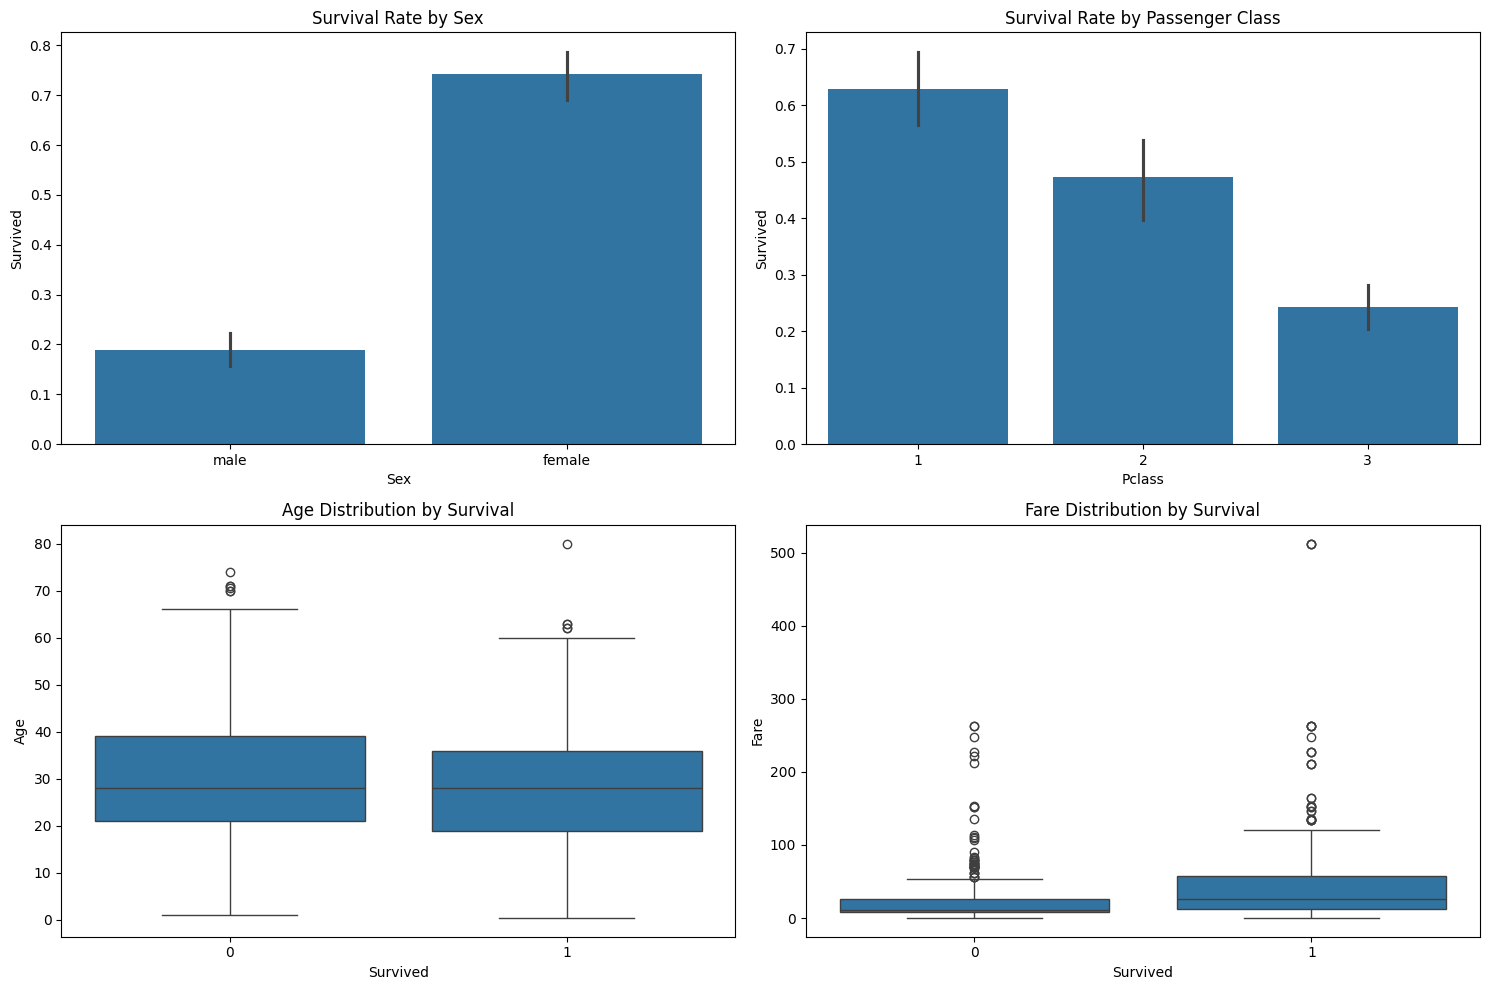


Survival Statistics:

Overall Survival Rate: 38.38%

Survival Rate by Sex:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64

Survival Rate by Class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0,0])
axes[0,0].set_title('Survival Rate by Sex')

sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Passenger Class')

sns.boxplot(data=df, x='Survived', y='Age', ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Survival')

sns.boxplot(data=df, x='Survived', y='Fare', ax=axes[1,1])
axes[1,1].set_title('Fare Distribution by Survival')

plt.tight_layout()
plt.show()

print("\nSurvival Statistics:")
print("\nOverall Survival Rate: {:.2f}%".format(df['Survived'].mean() * 100))
print("\nSurvival Rate by Sex:")
print(df.groupby('Sex')['Survived'].mean().round(3) * 100)
print("\nSurvival Rate by Class:")
print(df.groupby('Pclass')['Survived'].mean().round(3) * 100)

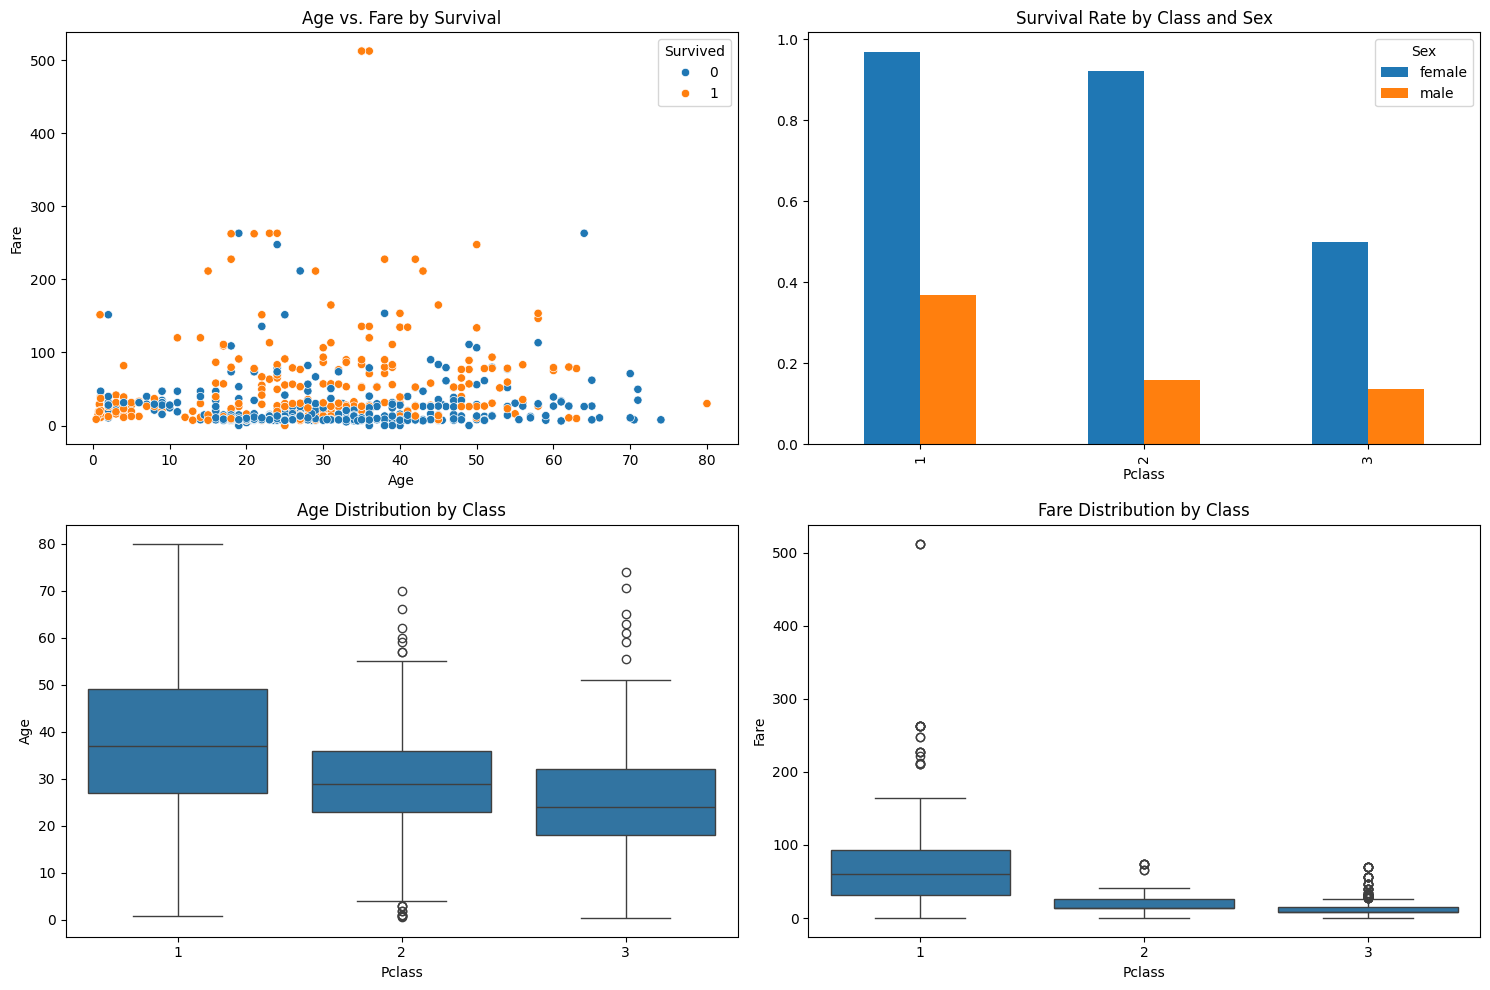


Key Insights:

1. Age and Survival:
Age
(0, 18]      0.504
(18, 35]     0.383
(35, 50]     0.399
(50, 100]    0.344
Name: Survived, dtype: float64

2. Fare and Survival:
Fare
(-0.001, 7.91]     0.197
(7.91, 14.454]     0.304
(14.454, 31.0]     0.455
(31.0, 512.329]    0.581
Name: Survived, dtype: float64


In [38]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', ax=axes[0,0])
axes[0,0].set_title('Age vs. Fare by Survival')

survival_by_class_sex = df.groupby(['Pclass', 'Sex'], observed=False)['Survived'].mean().unstack()
survival_by_class_sex.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Class and Sex')

sns.boxplot(data=df, x='Pclass', y='Age', ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Class')

sns.boxplot(data=df, x='Pclass', y='Fare', ax=axes[1,1])
axes[1,1].set_title('Fare Distribution by Class')

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("\n1. Age and Survival:")
print(df.groupby(pd.cut(df['Age'], bins=[0,18,35,50,100]), observed=False)['Survived'].mean().round(3))
print("\n2. Fare and Survival:")
print(df.groupby(pd.qcut(df['Fare'], q=4), observed=False)['Survived'].mean().round(3))

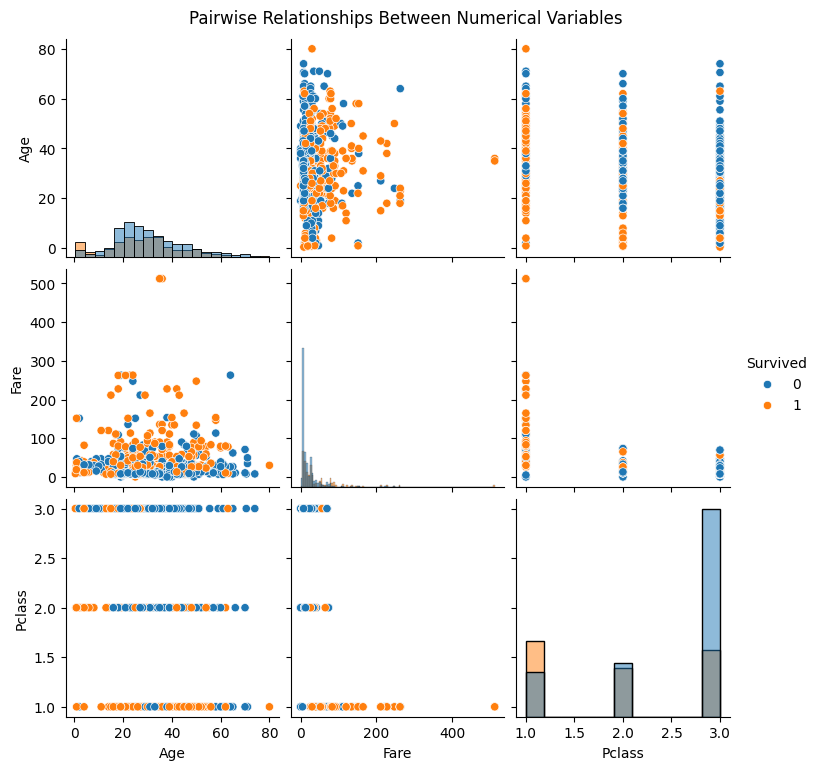

In [39]:
numerical_vars = ['Age', 'Fare', 'Survived', 'Pclass']
sns.pairplot(df[numerical_vars], hue='Survived', diag_kind='hist')
plt.suptitle('Pairwise Relationships Between Numerical Variables', y=1.02)
plt.show()

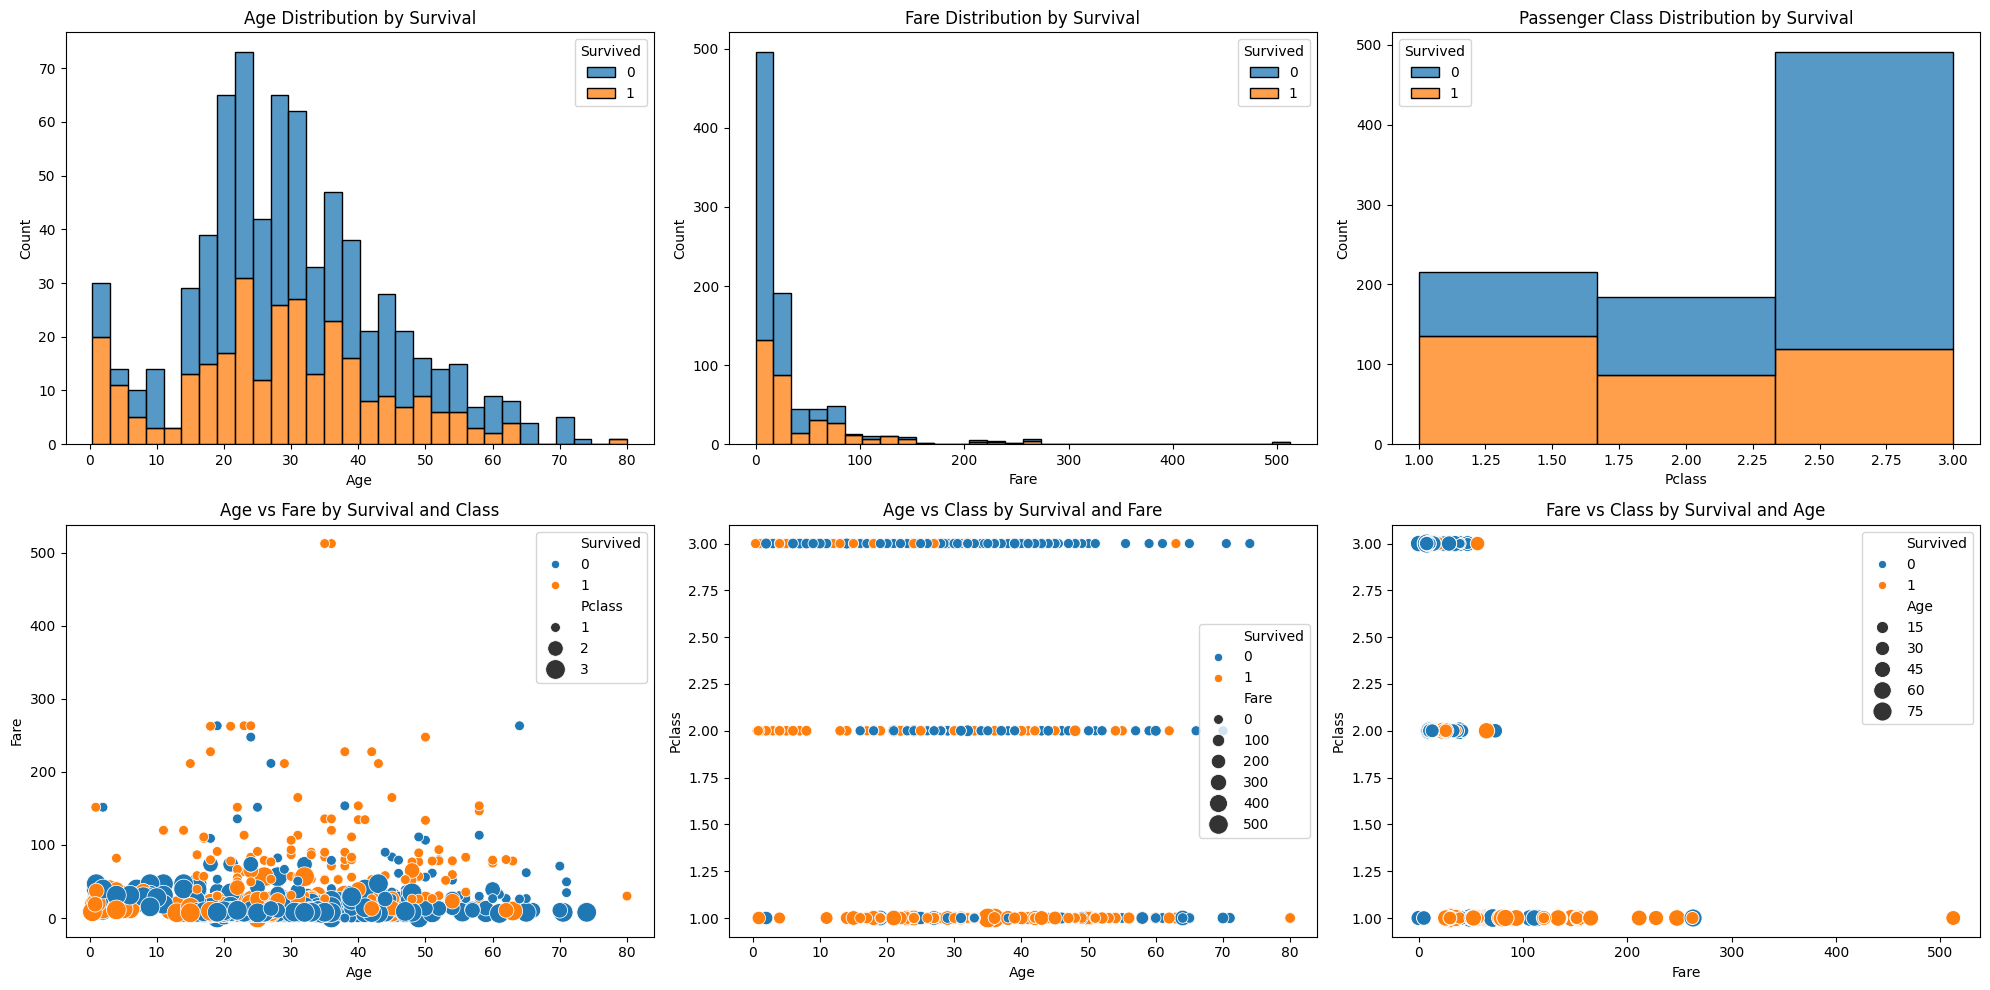

In [40]:

fig = plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
sns.histplot(data=df, x='Age', hue='Survived', multiple="stack", bins=30)
plt.title('Age Distribution by Survival')

plt.subplot(2, 3, 2)
sns.histplot(data=df, x='Fare', hue='Survived', multiple="stack", bins=30)
plt.title('Fare Distribution by Survival')

plt.subplot(2, 3, 3)
sns.histplot(data=df, x='Pclass', hue='Survived', multiple="stack", bins=3)
plt.title('Passenger Class Distribution by Survival')

plt.subplot(2, 3, 4)
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', size='Pclass', sizes=(50, 200))
plt.title('Age vs Fare by Survival and Class')

plt.subplot(2, 3, 5)
sns.scatterplot(data=df, x='Age', y='Pclass', hue='Survived', size='Fare', sizes=(50, 200))
plt.title('Age vs Class by Survival and Fare')

plt.subplot(2, 3, 6)
sns.scatterplot(data=df, x='Fare', y='Pclass', hue='Survived', size='Age', sizes=(50, 200))
plt.title('Fare vs Class by Survival and Age')

plt.tight_layout()
plt.show()

